# 📊 Global Sales Analysis

## 📌 Introducción

Este proyecto tiene como objetivo realizar un análisis exploratorio de un conjunto de datos de ventas globales que incluye información sobre regiones, países, tipos de producto, canal de venta, fechas de pedido y envío, así como métricas financieras como ingresos y ganancias.

A través de este análisis se busca identificar patrones de comportamiento en las ventas, determinar qué regiones o productos generan mayor rentabilidad y evaluar el desempeño de los diferentes canales de comercialización.

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv("10020Records.csv")

In [4]:
df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,5/2/2014,341417157,5/8/2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,7/5/2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2/1/2013,115456712,2/6/2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          100 non-null    object 
 1   Country         100 non-null    object 
 2   Item Type       100 non-null    object 
 3   Sales Channel   100 non-null    object 
 4   Order Priority  100 non-null    object 
 5   Order Date      100 non-null    object 
 6   Order ID        100 non-null    int64  
 7   Ship Date       100 non-null    object 
 8   Units Sold      100 non-null    int64  
 9   Unit Price      100 non-null    float64
 10  Unit Cost       100 non-null    float64
 11  Total Revenue   100 non-null    float64
 12  Total Cost      100 non-null    float64
 13  Total Profit    100 non-null    float64
dtypes: float64(5), int64(2), object(7)
memory usage: 8.3+ KB
None


In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [7]:
print(df.dtypes)

Region                    object
Country                   object
Item Type                 object
Sales Channel             object
Order Priority            object
Order Date        datetime64[ns]
Order ID                   int64
Ship Date         datetime64[ns]
Units Sold                 int64
Unit Price               float64
Unit Cost                float64
Total Revenue            float64
Total Cost               float64
Total Profit             float64
dtype: object


## 📌 Análisis

### Total Revenue by Item Type

In [8]:
revenue_by_item=df.groupby(["Item Type"])["Total Revenue"].sum().sort_values(ascending=False)
revenue_by_item

Item Type
Cosmetics          36601509.60
Office Supplies    30585380.07
Household          29889712.29
Baby Food          10350327.60
Clothes             7787292.80
Cereal              5322898.90
Meat                4503675.75
Personal Care       3980904.84
Vegetables          3089057.06
Beverages           2690794.60
Snacks              2080733.46
Fruits               466481.34
Name: Total Revenue, dtype: float64

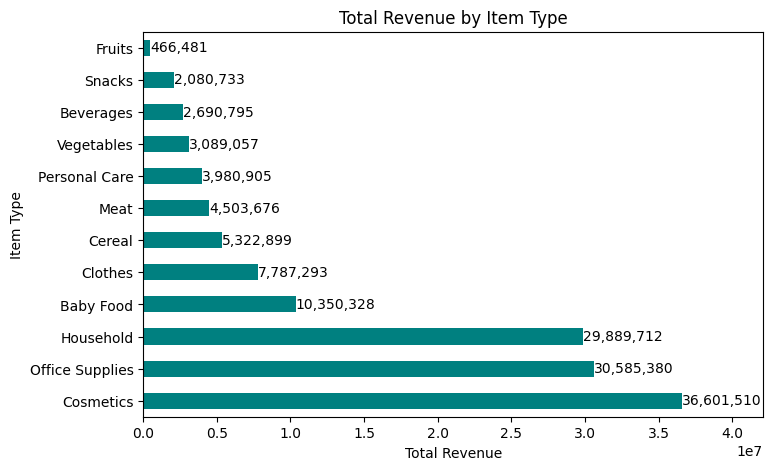

In [9]:
ax = revenue_by_item.plot(kind='barh', figsize=(8,5), color='teal')

plt.title("Total Revenue by Item Type")
plt.xlabel("Total Revenue")
plt.ylabel("Item Type")

# mostrar valores al final de las barras
for i, v in enumerate(revenue_by_item):
    ax.text(v, i, f'{v:,.0f}', va='center')

# dar más espacio a la derecha del gráfico
ax.set_xlim(0, revenue_by_item.max() * 1.15)

plt.show()

### Análisis

El análisis del ingreso total por tipo de producto muestra que Cosmetics es la categoría que genera el mayor nivel de ingresos, alcanzando aproximadamente 36.6 millones. Esto indica que los productos cosméticos representan una parte muy importante de las ventas totales dentro del conjunto de datos.

En segundo y tercer lugar se encuentran Office Supplies y Household, lo que sugiere que estos productos también tienen una alta demanda en los distintos mercados.

Por otro lado, categorías como Snacks y especialmente Fruits presentan los niveles más bajos de ingresos, siendo Fruits el producto con menor contribución al total de ventas.

### Total Revenue by Country and Item Type

In [10]:
revenue_country_item = df.groupby(["Country", "Item Type"])["Total Revenue"].sum().sort_values(ascending=False).reset_index()
revenue_country_item

,Country,Item Type,Total Revenue
0,Honduras,Household,5997054.98
1,Myanmar,Household,5513227.50
2,Lithuania,Office Supplies,5396577.27
3,Mexico,Household,4647149.58
4,Brunei,Office Supplies,4368316.68
...,...,...,...
92,Switzerland,Personal Care,22312.29
93,New Zealand,Fruits,20404.71
94,Kyrgyzstan,Vegetables,19103.44
95,Libya,Fruits,6279.09


### Análisis

Como podemos ver en el dataframe, el ingreso total por país y tipo de producto permite identificar qué categorías de productos generan mayores ventas en cada mercado. En los primeros lugares se observa que Honduras y Myanmar obtienen los mayores niveles de ingresos principalmente a partir de productos del tipo Household, mientras que Lithuania y Brunei destacan por sus ventas en Office Supplies.

Estos resultados sugieren que la demanda de productos puede variar significativamente entre países, ya que algunos mercados concentran sus ingresos en categorías específicas. Asimismo, se observa que los valores más bajos del ranking corresponden a productos como Fruits o Vegetables, lo que indica una menor contribución de estas categorías al ingreso total en comparación con otros tipos de productos.

### Total Revenue by Country

In [11]:
Total_revenue=df.groupby("Country")["Total Revenue"].sum().sort_values(ascending=False).reset_index()

In [12]:
Top10=Total_revenue.head(10)
Top10

,Country,Total Revenue
0,Honduras,6336545.48
1,Myanmar,6161257.90
2,Djibouti,6052890.86
3,Turkmenistan,5822036.20
4,Mexico,5643356.55
5,The Gambia,5449517.95
6,Lithuania,5396577.27
7,Rwanda,5253769.42
8,Azerbaijan,4478800.21
9,Brunei,4368316.68


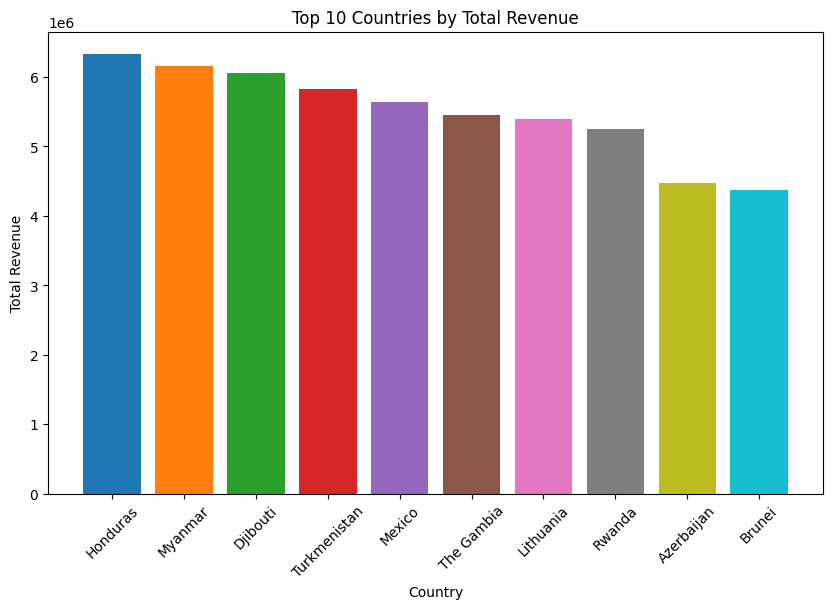

In [13]:
import numpy as np

colors = plt.cm.tab10(np.arange(10))

plt.figure(figsize=(10,6))
plt.bar(Top10["Country"], Top10["Total Revenue"], color=colors)

plt.title("Top 10 Countries by Total Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.show()

### Análisis

El análisis del ingreso total por país muestra que Honduras es el mercado con mayor nivel de ingresos, alcanzando aproximadamente 6.33 millones, seguido por Myanmar y Djibouti, que también presentan valores elevados de ventas.

Estos resultados indican que una parte importante de los ingresos se concentra en un grupo reducido de países. Mercados como Turkmenistan, Mexico y The Gambia también destacan dentro del ranking, contribuyendo de manera significativa al total de ventas.

### Total Profit by Country

In [14]:
profit_by_country = df.groupby("Country")["Total Profit"].sum()
Top10_Profit = profit_by_country.sort_values(ascending=False).head(10)
Top10_Profit = Top10_Profit.sort_values()
Top10_Profit

Country
Rwanda         1417493.49
Mexico         1457942.76
Switzerland    1512729.45
Azerbaijan     1512926.83
Iceland        1541705.29
Honduras       1609947.52
Samoa          1678540.98
Pakistan       1719922.04
Myanmar        1802771.70
Djibouti       2425317.87
Name: Total Profit, dtype: float64

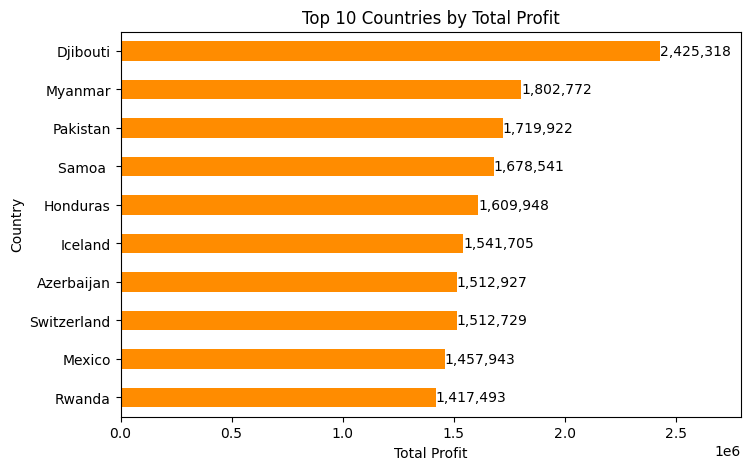

In [15]:
ax = Top10_Profit.plot(kind='barh', figsize=(8,5), color='darkorange')

plt.title("Top 10 Countries by Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Country")

# mostrar valores al final de las barras
for i, v in enumerate(Top10_Profit):
    ax.text(v, i, f'{v:,.0f}', va='center')

# agregar espacio a la derecha para que no se corte el número
ax.set_xlim(0, Top10_Profit.max() * 1.15)

plt.show()

### Análisis

El análisis del beneficio total por país muestra que Djibouti es el país que genera la mayor ganancia, con aproximadamente 2.43 millones, seguido por Myanmar y Pakistan, que también presentan niveles elevados de rentabilidad.

Un aspecto interesante es que Honduras, a pesar de ser el país con mayor nivel de ingresos en el análisis anterior, solo ocupa el sexto lugar en términos de beneficio total. Esto indica que un mayor volumen de ventas no necesariamente se traduce en una mayor rentabilidad.

En general, este resultado resalta la importancia de analizar no solo los ingresos, sino también las ganancias, ya que algunos mercados pueden generar mayores beneficios incluso sin tener el mayor volumen de ventas.

### Profit Margin

In [16]:
df["Profit Margin"] = df["Total Profit"] / df["Total Revenue"]

In [17]:
df[['Total Revenue','Total Profit','Profit Margin']].sort_values(by='Profit Margin', ascending=True)

,Total Revenue,Total Profit,Profit Margin
19,2492526.12,337937.60,0.135580
37,2011149.63,272672.40,0.135580
49,824431.86,159832.50,0.193870
2,1158502.59,224598.75,0.193870
4,3296425.02,639077.50,0.193870
...,...,...,...
48,856973.76,575916.48,0.672035
81,861563.52,579000.96,0.672035
63,668356.48,449159.04,0.672035
56,1082418.40,727423.20,0.672035


### Análisis

En esta sección se calcula el margen de utilidad (Profit Margin), el cual se obtiene dividiendo el Total Profit entre el Total Revenue. Este indicador permite medir qué proporción de los ingresos se convierte realmente en ganancia.

Un margen de utilidad más alto indica que una mayor parte de los ingresos se transforma en beneficio, lo que refleja una mayor eficiencia en la generación de ganancias. Por el contrario, un margen más bajo puede indicar mayores costos o una menor rentabilidad en las ventas.

Este indicador resulta fundamental para complementar el análisis de ingresos y ganancias, ya que permite evaluar la rentabilidad real de las operaciones, más allá del volumen total de ventas.

### Profit Margin by Country

In [18]:
profit_margin_country = df.groupby('Country')['Profit Margin'].mean().sort_values()

In [19]:
top10_margin = profit_margin_country.tail(10)
top10_margin

Country
Mali             0.465171
Albania          0.672035
Cote d'Ivoire    0.672035
Lebanon          0.672035
Fiji             0.672035
Cape Verde       0.672035
Bangladesh       0.672035
Macedonia        0.672035
Madagascar       0.672035
Belize           0.672035
Name: Profit Margin, dtype: float64

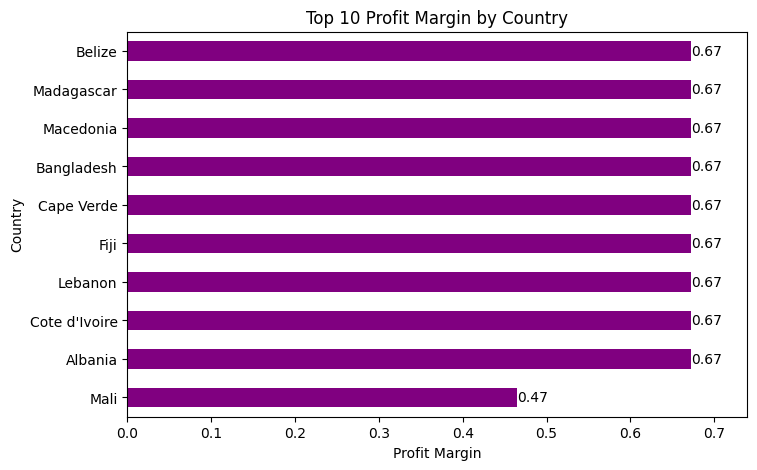

In [35]:
ax = top10_margin.plot(kind='barh', figsize=(8,5), color='purple')

plt.title("Top 10 Profit Margin by Country")
plt.xlabel("Profit Margin")
plt.ylabel("Country")

for i, v in enumerate(top10_margin):
    ax.text(v, i, f'{v:.2f}', va='center')

ax.set_xlim(0, top10_margin.max() * 1.10)

plt.show()

### Análisis

El análisis del margen de utilidad por país muestra que varios mercados presentan niveles muy altos de rentabilidad. Entre ellos destacan Albania, Cote d'Ivoire, Lebanon, Fiji, Cape Verde, Bangladesh, Macedonia, Madagascar y Belize, todos con un margen de utilidad cercano a 0.67, lo que significa que aproximadamente el 67% de los ingresos se convierten en ganancia.

Por su parte, Mali también presenta un margen de utilidad elevado, aunque ligeramente inferior en comparación con los demás países del ranking.

Estos resultados indican que algunos mercados pueden generar altos niveles de rentabilidad incluso sin tener los mayores ingresos totales, lo que refuerza la importancia de analizar el margen de utilidad además de las ventas o las ganancias totales.

### Revenue by Region

In [21]:
region_revenue=df.groupby("Region")["Total Revenue"].sum().sort_values(ascending=False).reset_index()
region_revenue

,Region,Total Revenue
0,Sub-Saharan Africa,39672031.43
1,Europe,33368932.11
2,Asia,21347091.02
3,Australia and Oceania,14094265.13
4,Middle East and North Africa,14052706.58
5,Central America and the Caribbean,9170385.49
6,North America,5643356.55


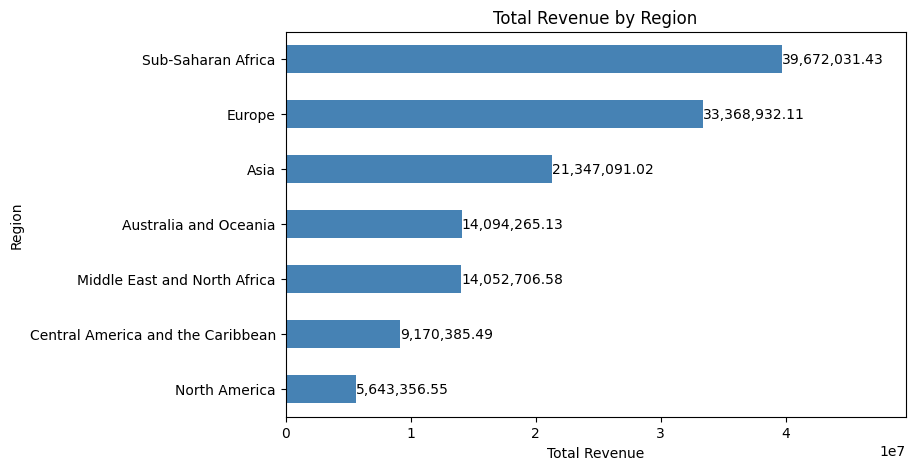

In [31]:
region_revenue = df.groupby('Region')['Total Revenue'].sum().sort_values()

ax = region_revenue.plot(kind='barh', figsize=(8,5), color='steelblue')

plt.title("Total Revenue by Region")
plt.xlabel("Total Revenue")
plt.ylabel("Region")

for i, v in enumerate(region_revenue.values):
    ax.text(v, i, f'{v:,.2f}', va='center')

ax.set_xlim(0, region_revenue.max() * 1.25)

plt.show()

### Análisis

El análisis del ingreso total por región muestra que Sub-Saharan Africa es la región que genera el mayor nivel de ingresos, alcanzando aproximadamente 39.67 millones. En segundo lugar se encuentra Europe, con más de 33 millones, seguida por Asia, que también contribuye de manera importante al total de ventas.

Otras regiones como Australia and Oceania y Middle East and North Africa presentan niveles de ingresos intermedios, mientras que Central America and the Caribbean y North America registran los valores más bajos dentro del conjunto de datos.

En general, este análisis permite identificar qué regiones concentran la mayor parte de las ventas, proporcionando una visión más amplia de la distribución geográfica de los ingresos.

### Profit by Region

In [24]:
region_profit=df.groupby("Region")["Total Profit"].sum().sort_values(ascending=False).reset_index()
region_profit

,Region,Total Profit
0,Sub-Saharan Africa,12183211.40
1,Europe,11082938.63
2,Asia,6113845.87
3,Middle East and North Africa,5761191.86
4,Australia and Oceania,4722160.03
5,Central America and the Caribbean,2846907.85
6,North America,1457942.76


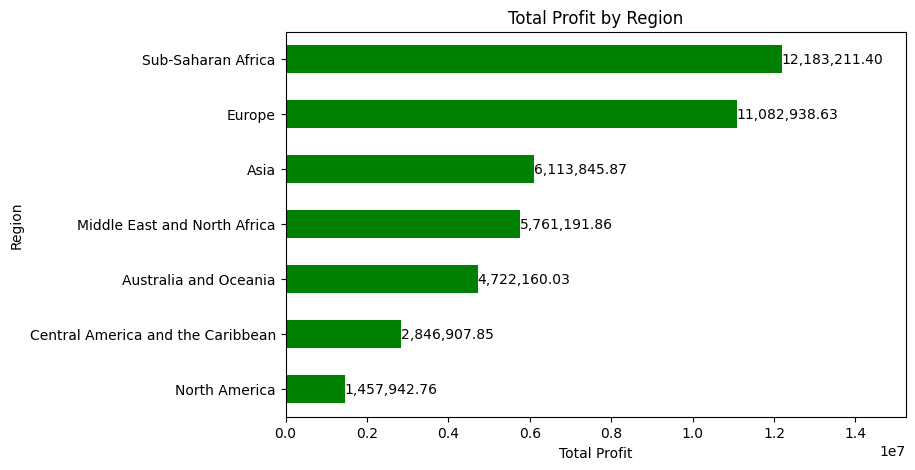

In [30]:
region_profit = df.groupby('Region')['Total Profit'].sum().sort_values()

ax = region_profit.plot(kind='barh', figsize=(8,5), color='green')

plt.title("Total Profit by Region")
plt.xlabel("Total Profit")
plt.ylabel("Region")

for i, v in enumerate(region_profit.values):
    ax.text(v, i, f'{v:,.2f}', va='center')

ax.set_xlim(0, region_profit.max() * 1.25)

plt.show()

### Análisis 

El análisis de ganancia total por región muestra que Sub-Saharan Africa genera el mayor nivel de beneficios dentro del conjunto de datos, alcanzando aproximadamente 12.18 millones en ganancias. En segundo lugar se encuentra Europe, con alrededor de 11.08 millones, lo que también refleja un fuerte desempeño en términos de rentabilidad.

Asia ocupa la tercera posición con más de 6.11 millones en ganancias, seguida por Middle East and North Africa y Australia and Oceania, que presentan niveles de beneficio similares pero ligeramente inferiores.

Por otro lado, Central America and the Caribbean y North America registran los valores más bajos de ganancias dentro del análisis regional.

En general, este análisis permite identificar qué regiones contribuyen más significativamente a la rentabilidad total del negocio y complementa el análisis de ingresos, proporcionando una visión más completa del desempeño financiero en las diferentes regiones.

## Conclusión

A lo largo de este proyecto se realizó un análisis exploratorio de datos con el objetivo de comprender el desempeño de las ventas desde distintas perspectivas, incluyendo productos, países y regiones. Los resultados muestran que algunas categorías de productos generan una parte significativa de los ingresos totales, lo que permite identificar cuáles son los productos más importantes para el negocio.

A nivel geográfico, el análisis por países reveló que ciertos mercados concentran una gran parte de los ingresos y ganancias. Sin embargo, también se observó que un mayor volumen de ventas no siempre implica una mayor rentabilidad, lo cual se evidenció al analizar el profit margin.

Además, el análisis por regiones mostró que Sub-Saharan Africa y Europe lideran tanto en ingresos como en ganancias dentro del conjunto de datos, lo que indica que estas regiones tienen un impacto importante en el desempeño general del negocio.

En conjunto, este análisis demuestra la importancia de evaluar diferentes indicadores —como ingresos, ganancias y margen de utilidad— para obtener una comprensión más completa del rendimiento de las ventas y apoyar la toma de decisiones estratégicas basadas en datos.